# Predict the next four video frames with DAVIS

Follow six steps: open your saved project → inspect a real clip → change and save experiment settings → review files and the exact command → run the saved script → plot recorded scores.

This **three-iteration process demo** uses the original bounded DAVIS task. It is outside the paper's four experiments, not a paper artifact or a video-generation benchmark. Each input has 8 RGB context frames; the target is the next 4. The original 60 Train / 15 Validation / 15 Final sequence split remains intact. Validation guides the agent; Final clips are not used. The archived images below come from a real three-iteration run. Its first candidate failed Health; the next two passed. See the [recorded example](https://github.com/yuema137/siderius-exp/blob/main/tutorials/supplementary/davis/example/README.md) for scores, source identity and limits. A newly initialized notebook clears these outputs for your own run.

Follow the [DAVIS setup guide](https://github.com/yuema137/siderius-exp/blob/main/tutorials/supplementary/davis/README.md). Before paid execution, run the [hardware check](https://github.com/yuema137/siderius-exp/blob/main/tutorials/shared/hardware/README.md) against your saved JSON: Linux, a supported NVIDIA GPU, working accounting and room for the saved allowance (initially 10 GiB). CPU/Intel training is unsupported; AMD is experimental and lacks the required tutorial accounting. Keep the 0.833 GB archive plus extracted frames, environments and results. Host RAM use depends on batch/model/loading; no universal minimum or peak has been qualified. CPU image inspection is separate from GPU training.


## 1. Open your saved project

Use the initializer in the README first. Your external folder contains:

```text
project/
  project.json
  tasks/davis/compositions/bounded_qualification.yaml
  tasks/davis/data/manifests/       original clip and sequence identities
  tasks/davis/declared/             tensor contract, metrics and Health
  tasks/davis/runtime/              task-owned frame decoder
  tasks/davis/plugins/              exact-L1 loss, metrics and reference model
  experiments/davis-demo.json       editable run parameters
  experiments/workflow.json         fixed native workflow choices
  llm/agents.json                   model routes and key names, never key values
  scripts/run-davis.sh              saved launch entry point
  notebooks/davis_tutorial.ipynb
  runs/davis_demo_001/              created only by launch
  plots/                           recorded score images and CSV
```

The dataset stays at your separately supplied `DAVIS_DATA` directory; initialization does not copy it. Set `TUTORIAL_HOME` before starting Jupyter. In the next cell, `SELECTED_EXPERIMENT` and `SELECTED_SCRIPT` select an existing saved pair; after saving a variant the notebook updates both for you.


In [ ]:
import json
import os
import sys
from pathlib import Path

home = os.environ.get("TUTORIAL_HOME")
if not home:
    raise RuntimeError(
        "Export TUTORIAL_HOME to your initialized external project and restart Jupyter."
    )
PROJECT = Path(home).expanduser().resolve()
if not (PROJECT / "project.json").is_file():
    raise RuntimeError(
        "Missing project.json; initialize a new external DAVIS project using the README."
    )
binding = json.loads((PROJECT / "project.json").read_text())
EXP_CHECKOUT = Path(binding["exp_checkout"])
if Path(sys.prefix).resolve() != (EXP_CHECKOUT / ".venv").resolve():
    raise RuntimeError(
        "Select the SIDERIUS DAVIS tutorial kernel from this exp checkout."
    )
sys.dont_write_bytecode = True
os.chdir(EXP_CHECKOUT)
from IPython.display import Markdown, display

from tutorials.supplementary.davis.data import scope_counts, show_clip
from tutorials.supplementary.davis.demo import plot_results, review, run_demo
from tutorials.supplementary.davis.project import save_variant
from tutorials.supplementary.davis.settings import DavisExperiment

SELECTED_EXPERIMENT = "davis-demo"  # Or your saved variant name.
EXPERIMENT = PROJECT / "experiments" / f"{SELECTED_EXPERIMENT}.json"
SCRIPT = (
    PROJECT
    / "scripts"
    / (
        "run-davis.sh"
        if SELECTED_EXPERIMENT == "davis-demo"
        else f"run-{SELECTED_EXPERIMENT}.sh"
    )
)
settings = DavisExperiment.model_validate_json(EXPERIMENT.read_text())
print(
    f"Project: {PROJECT}\nExperiment: {EXPERIMENT}\nScript: {SCRIPT}\nRaw data: {settings.data_dir}\nFresh run workspace: {settings.workspace}"
)

## 2. Look at one real training clip

The task decoder reads 12 consecutive RGB images, resizes each to height 128 × width 224 with bilinear interpolation, and scales pixels to [0,1]. It returns context `[3,8,128,224]` and target `[3,4,128,224]`. The first eight images are input; the last four are training targets, **not predictions**.

The bounded manifests contain the first window of each original sequence: 60 Train, 15 Validation and 15 unused Final clips. The table below asks the real task to select the scopes with seed 42; actual attempt seeds can select different clips, without crossing the original sequence boundary. Default Trial uses 15 training clips, Formal 30; both evaluate 15 validation clips.


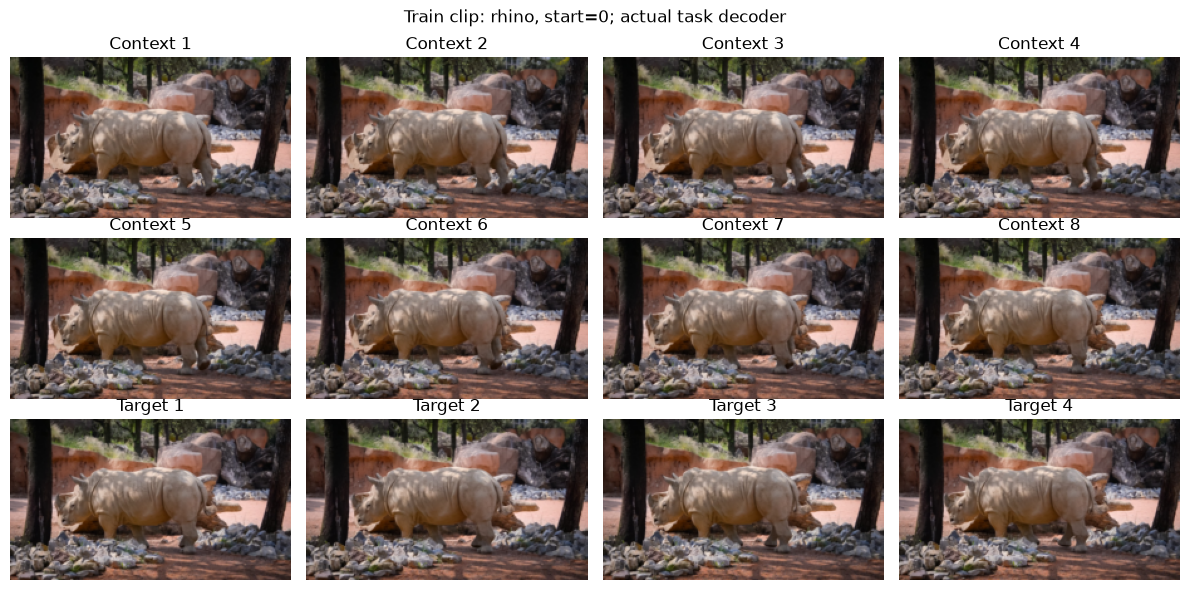

In [ ]:
settings = DavisExperiment.model_validate_json(EXPERIMENT.read_text())
counts = scope_counts(settings)
rows = "\n".join(
    f"| {c.name} | {c.fraction:g} | {c.clips} | {c.sequences} |" for c in counts
)
display(
    Markdown("| Scope | Fraction | Clips | Sequences |\n|---|---:|---:|---:|\n" + rows)
)
figure = show_clip(settings)
display(figure)

## 3. Change and save an experiment

**Task package** means scientific meaning: the decoder, 8→4 tensor contract, original sequence split, exact-L1 training loss, MSE score (lower is better) and blocking prediction-dispersion Health check. Inspect the copied composition, manifests and `declared/` files. You may edit the copied task description to explain your goal, but this tutorial deliberately preserves its original decoder, manifests, objective and Health policy. Changing those scientific rules needs a separate task/experiment; this helper does not silently regenerate a split. After editing the task description, restart the kernel before reviewing it again: stale cached configuration is refused.

**Experiment** means how to run that task. Edit `CHANGES` below, set `SAVE_VARIANT=True` once, and run the cell. It writes a new JSON and shell script, gives the run a fresh workspace, and prints all three paths. It does not overwrite the starting experiment or earlier results. For a **later Run All or reopened notebook**, set `SELECTED_EXPERIMENT` in section 1 to your saved name (for example `"davis-four-001"`) and set `SAVE_VARIANT=False` here. Section 1 otherwise selects `davis-demo` again. Continuing directly from this save cell already uses the new pair.

| Change | Example | Meaning |
|---|---|---|
| `iterations` | `4` | Four generated-model iterations instead of three |
| `rounds` | `2` | Minimum two rounds: a Trial and a Formal round |
| `epochs` | `2` | Epoch ceiling for each attempt |
| `trial_train_fraction` | `0.25` | 15 of the original 60 Train clips |
| `formal_train_fraction` | `0.5` | 30 of the original 60 Train clips |
| `trial_eval_fraction`, `formal_eval_fraction` | `1.0` | All 15 Validation clips in each phase |
| `trial_minutes`, `formal_minutes` | `2.0`, `5.0` | Native phase training allowances in minutes |
| `vram_gib` | `10.0` | Shared VRAM allowance, not measured model usage |
| `trial_vram_gib`, `formal_vram_gib` | `None` | Optional overrides; absent means use `vram_gib` |

Fractions range from 0.01 to 1. The task selects `max(1, round(fraction × clip_count))`; Python's round-to-even applies. For example, `formal_train_fraction=0.75` selects 45 training clips. Every selected clip still has 8 context and 4 target frames. Epoch `train_portion` is fixed at 1 because this task rejects fractional epoch sampling. Formal scope is explicitly operator-controlled, so the agent cannot replace your saved Formal fraction. Data Analysis, literature review and human advice are disabled here.


In [ ]:
SAVE_VARIANT = False
VARIANT_NAME = "davis-four-001"
CHANGES = {"iterations": 4}
if SAVE_VARIANT:
    EXPERIMENT, SCRIPT = save_variant(
        PROJECT, EXPERIMENT, name=VARIANT_NAME, changes=CHANGES
    )
    settings = DavisExperiment.model_validate_json(EXPERIMENT.read_text())
    print(
        f"Selected saved variant: {EXPERIMENT}\nScript: {SCRIPT}\nFresh run workspace: {settings.workspace}\nFollowing cells use this pair; set SAVE_VARIANT=False after saving."
    )
else:
    print("Using the selected saved JSON unchanged. Save-as is disabled.")


## 4. Check the saved files before running

Read the full saved-settings table and the two exact shell commands below. Check: selected task composition and original manifests; four scope fractions, iterations, epochs and budgets in the saved JSON; operator Formal scope in workflow.json; all-Luna routes in `llm/agents.json`; a fresh workspace; correct external data directory; and matching script/JSON paths. Defaults are shown as values, not hidden.

The preview checks the paired installations and local inputs without API/GPU work. Archive SHA-256 and ten frozen decoded-window probes are checked on launch; this does not cryptographically verify every extracted image. The hardware-only command in the README reports current GPU capacity/occupancy/quota and host RAM/disk observations, but does not reserve resources or prove a future model fits. Export your own `OPENAI_API_KEY` in the Jupyter-launching terminal; never place a key in a notebook or JSON. Cheap Luna routing tests the process, not scientific quality.


In [ ]:
display(Markdown(review(EXPERIMENT, SCRIPT)))
RUN_NATIVE_PREVIEW = True
preview_settings = DavisExperiment.model_validate_json(EXPERIMENT.read_text())
if RUN_NATIVE_PREVIEW and preview_settings.workspace.exists():
    print(
        "Workspace exists: native launch preview skipped. Section 5 checks completed-result reuse; section 6 plots records independently."
    )
elif RUN_NATIVE_PREVIEW:
    import subprocess

    subprocess.run(["bash", str(SCRIPT)], check=True)
else:
    print("Native preview skipped; this is not launch qualification.")

## 5. Run the saved script — API and GPU effects

**Run All reaches this cell.** With `RUN_QUICK_DEMO=True`, the notebook invokes the saved script with `--launch`. Set it to `False` for inspection only. The script, not the notebook, launches native training and writes results. Outside Jupyter use `bash /absolute/project/scripts/run-davis.sh --launch`, or the exact variant command printed above.

An unchanged completed run is reused without launching again. If inputs changed or a run stopped early, retain its evidence and save a fresh variant. Phase allowances and notebook timeout are not a whole-run API spending cap. This demonstrates execution; Health failures and low scores remain useful evidence and are not reasons to rerun until a good score appears.


In [ ]:
RUN_QUICK_DEMO = True
NOTEBOOK_TIMEOUT_SECONDS = 3600
if RUN_QUICK_DEMO:
    result = run_demo(EXPERIMENT, SCRIPT, timeout_seconds=NOTEBOOK_TIMEOUT_SECONDS)
    print(result)
else:
    print("Live search disabled: no saved script launched, no API/GPU work.")

## 6. Plot the scores that actually exist

The plot reads native Formal `mse` records: **lower is better**. It uses the original Validation clips, not unused Final clips. Filled points need successful scored execution and passing recorded Health checks. Invalid/rejected scored attempts are hollow; absent scores are not invented zeros. The best displayed score is diagnostic teaching output, not proof of scientific quality.

The plot cell writes PNG, SVG and CSV under `plots/<saved-experiment-name>/`. Select another saved JSON in `PLOT_EXPERIMENT` to plot an older run without launching it. Inspect native manifests/records under the run workspace for each outcome. The notebook `.console.log` and `.notebook-run.json` are siblings of that directory; a direct shell launch writes console output to its terminal. In the archived example, iteration 1 is hollow because its predictions failed the unchanged dispersion Health check. Its manifest says `no_records`: no valid winner was selected, although the raw scored attempt remains available to plot. Iterations 2 and 3 passed. The “Current best” curve tracks the best displayed raw score; it is not the native scientific chain incumbent, and a raw minimum alone does not establish validity.


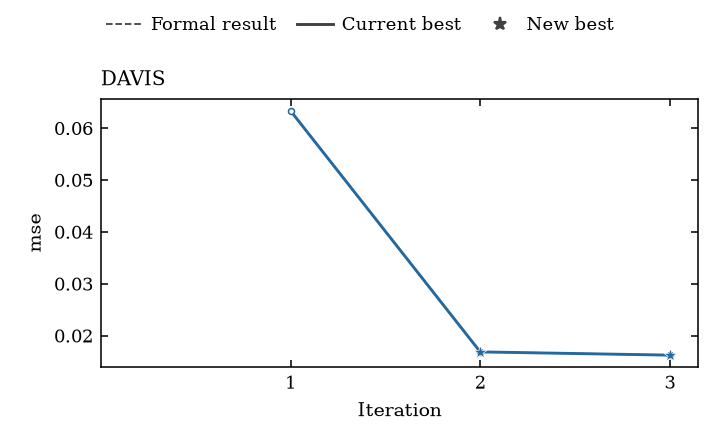

In [ ]:
PLOT_EXPERIMENT = (
    EXPERIMENT  # Or Path("/absolute/project/experiments/earlier-run.json")
)
PLOT_OUTPUT = PROJECT / "plots" / PLOT_EXPERIMENT.stem
plot_settings = DavisExperiment.model_validate_json(PLOT_EXPERIMENT.read_text())
if plot_settings.workspace.is_dir():
    try:
        display(plot_results(PLOT_EXPERIMENT, PLOT_OUTPUT))
        print(f"Saved PNG/SVG/CSV to {PLOT_OUTPUT}")
    except ValueError as error:
        print(f"Plot unavailable: {error}")
else:
    print(
        "No result workspace yet. Run the saved script when authorized, or select an existing PLOT_EXPERIMENT."
    )